In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Part (a): Qualitative Analysis**

**Part (i):**

In [2]:
# Potential
def V(x):
    if abs(x) <= a:
        return -V0*np.sqrt(a**2 - x**2)
    else:
        return 0

# Parameters
a = 1
V0 = 10

# Space-grid
xi, xf = -3, 3
dx = 1e-2
N = int((xf-xi)/dx) + 1
xs = np.linspace(xi, xf, N)

# Potential values
Vs = [V(x) for x in xs]

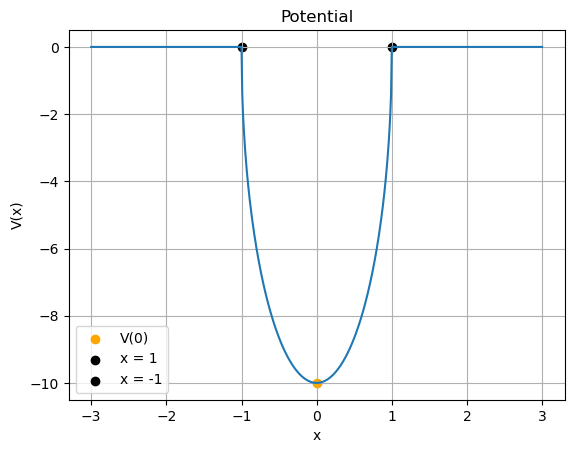

In [3]:
plt.plot(xs, Vs)
plt.scatter(0, -V0, color = "orange", label = "V(0)")
plt.scatter(1, V(1), color = "black", label = "x = 1")
plt.scatter(-1, V(-1), color = "black", label = "x = -1")
plt.xlabel("x")
plt.ylabel("V(x)")
plt.title("Potential")

plt.legend()
plt.grid()
plt.show()

The Schrodinger's equation in reduced form:
$$\psi''(x) = [V(x) - E] \psi(x)$$

For bound states, the wavefunction satisfies $\psi(x) \rightarrow 0$ as $x \rightarrow \infty$. Hence, we look for such states outside the well.

Outside the well, $V(x) = 0$. The Schrodinger's equation simplifies to:
$$\psi'' = -E\psi$$

**Case 1: $E \ge 0$**

$$\psi'' + E\psi = 0$$
This gives a general solution of the form:
$$\psi(x) = A\,e^{i\sqrt{E}x} + B\,e^{-i\sqrt{E}x}$$

It is an oscillatory solution and does not decay. Hence, it is not a bound state.

**Case 2: $E < 0$**

$$\psi'' = -E\psi = -(-|E|)\psi = |E|\psi$$
This gives a general solution of the form:
$$\psi(x) = A\,e^{\kappa x} + B\,e^{-\kappa x}$$
where $\kappa = \sqrt{|E|} = \sqrt{-E}$.

For decaying solutions:
1. $x > a \implies A = 0$
2. $x < a \implies B = 0$

This can be combined and written as:
$$\psi(x) \sim e^{-\kappa |x|}$$
which gives a decaying solution. Hence, for bound states, $E < 0$.

**Why $E \ge V_0$?**

Inside the well, $V(x) > -V_0$. If $E<-V_0 \implies E<V(x)$. This means that there is no classically allowed region for the particle anywhere. The wavefunction vanishes everywhere. This is not a physically meaningful solution.

Hence, for bound states, $0 > E > -V_0$

**Part (ii):**

Asymptotic solution:
$$\psi(x) \sim e^{-\kappa |x|}$$

At $x = \pm 3$:
$$\psi(x) \sim e^{-3\kappa}$$

Since $E>0 \implies \kappa > 0 \implies \psi(\pm 3) \approx 0$. Hence $x = \pm 3$ is a good approximation for boundary condition.

## **Part (b): Shooting method**

We consider:

$\psi = y[0] \\
\psi' = y[1]$

The 2 differential equations are:
$$\frac{d\psi}{dt} = \psi' \implies \frac{dy[0]}{dt} = y[1] \\[10 pt]
\frac{d\psi'}{dt} = (V - E)\psi \implies \frac{dy[1]}{dt} = (V-E)y[0]$$

These can be combined and written as:
$$ \frac{d}{dt}
\begin{pmatrix}
    y[0] \\
    y[1]
\end{pmatrix} =
\begin{pmatrix}
    y[1] \\
    (V-E) y[0]
\end{pmatrix}
$$

In [4]:
# RK4
def rk4(f1, x, y, h, E):
    k1 = h * f1(x, y, E)
    k2 = h * f1(x + h / 2, y + k1 / 2, E)
    k3 = h * f1(x + h / 2, y + k2 / 2, E)
    k4 = h * f1(x + h, y + k3, E)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

# RK4 caller
def caller(fn, y_ini, N, xs, h, E):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)

    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = rk4(fn, x, y, h, E)
    return ys

# dv/dt
def f1(x, y, E):
    return np.array([y[1], (V(x)-E)*y[0]])

**Part (i):**

The RK4 integration function f1 uses $V(x)$, not $\frac{dV}{dx}$, hence it does not cause a problem even if $\frac{dV}{dx} \rightarrow \infty$

In [5]:
# Space grid for left integration
xm = 0.5
xil, xfl = -3, xm
dx = 1e-3
Nl = int((xfl - xil)/dx)+1
xsl = np.linspace(xil, xfl, Nl)

# Trial energy
E = -5		
kappa = np.sqrt(-E)
Y0l = np.array([np.exp(-3*kappa), kappa*np.exp(-3*kappa)])

# Implementing RK4
Ysl = caller(f1, Y0l, Nl, xsl, dx, E)

**Part (ii):**

At $x = \pm 1$, V(x) changes rapidly. RK4 assumes that the function is smooth. This assumption is broken. Hence, the integration must not be started at $x = \pm1$ 

In [18]:
# Space grid for right integration
xir, xfr = xm, 3
dx = 1e-3
Nr = int((xfr - xir)/dx)+1
xsr = np.linspace(xir, xfr, Nr)

# Trial energy
E = -5		
kappa = np.sqrt(-E)
Y0r = np.array([np.exp(-3*kappa), -kappa*np.exp(-3*kappa)])

# Implementing RK4
Ysr = caller(f1, Y0r, Nr, xsr, dx, E)

**Part (iii):**

The Schrodinger equation is linear. Hence, the left and right solutions can differ by a constant. If we match $\psi$ and $\psi'$ separately at the matching point, then:
$$\psi_L(x_m) = C\psi_R(x_m) \\[10 pt]
\psi_L'(x_m) = C\psi_R'(x_m)$$

This means that we have to fix the normalisation constant beforehand, which is unknown. Instead, if we match the derivative $\frac{\psi'}{\psi}$ then:
$$\psi \rightarrow C\psi \\[10 pt]
\frac{\psi'}{\psi} \rightarrow \frac{(C\psi)'}{C\psi} = \frac{\psi'}{\psi}$$

The normalisation constant does not alter the result.

The eigenvalue condition is:
$$F(E) = 0$$

This ensures that both $\psi$ and $\psi'$ is continuous.


In [90]:
# Shooting method
def F(E, xm, xil, xfr, dx):
	# LEFT INTEGRATION
    # Space grid
	xil, xfl = xil, xm
	Nl = int((xfl - xil)/dx)+1
	xsl = np.linspace(xil, xfl, Nl)
	# Initial conditions
	kappa = np.sqrt(-E)
	Y0l = np.array([np.exp(xil*kappa), kappa*np.exp(xil*kappa)])
	# Implementing RK4
	Ysl = caller(f1, Y0l, Nl, xsl, dx, E)

	# RIGHT INTEGRATION
	# Space grid
	xir, xfr = xm, xfr
	Nr = int((xfr - xir)/dx)+1
	xsr = np.linspace(xfr, xir, Nr)
	# Initial conditions
	kappa = np.sqrt(-E)
	Y0r = np.array([np.exp(-xfr*kappa), -kappa*np.exp(-xfr*kappa)])
	# Implementing RK4
	Ysr = caller(f1, Y0r, Nr, xsr, -dx, E)

	# Mismatch function
	psil, d_psil = Ysl[:, 0], Ysl[:, 1]
	psir, d_psir = Ysr[:, 0], Ysr[:, 1]
	il, ir = np.argmin(np.abs(xsl - xm)),  np.argmin(np.abs(xsr - xm))
	
	return d_psil[il]/psil[il] - d_psir[ir]/psir[ir]

## **Part (c): Finding the eigenvalues**

**Part (i):**

In [91]:
# Energy grid
Ei, Ef = -V0, 0
dE = 1e-1
N = int((Ef-Ei)/dE)+1
Es = np.linspace(Ei, Ef, N)

# Implementinf shooting method
xil, xfr = -3, 3
dx = 1e-2
Fs = [F(E, xm, xil, xfr, dx) for E in Es]

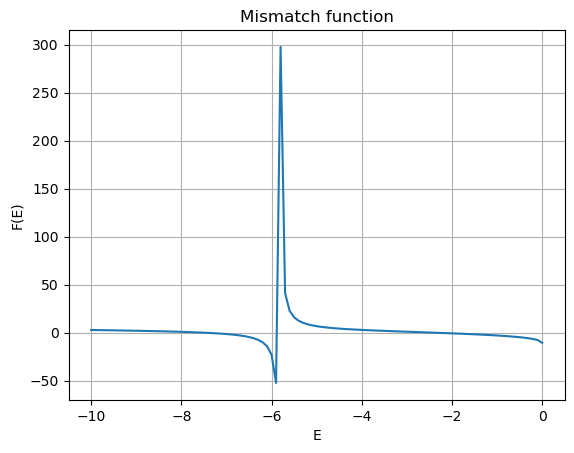

In [92]:
# Plotting
plt.plot(Es, Fs)
plt.xlabel("E")
plt.ylabel("F(E)")
plt.title("Mismatch function")
plt.grid()
plt.show()

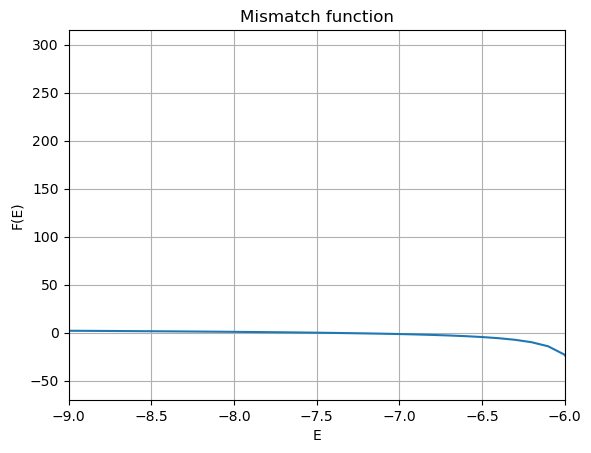

In [94]:
plt.plot(Es, Fs)
plt.xlabel("E")
plt.ylabel("F(E)")
plt.title("Mismatch function")
plt.xlim(-9, -6)
# plt.ylim(-10, 100)
plt.grid()
plt.show()

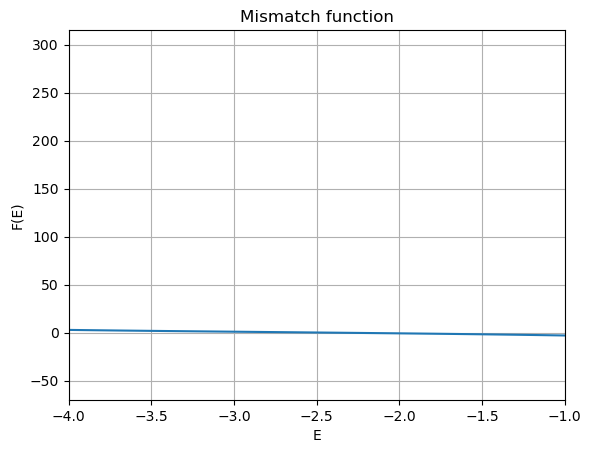

In [95]:
plt.plot(Es, Fs)
plt.xlabel("E")
plt.ylabel("F(E)")
plt.title("Mismatch function")
plt.xlim(-4, -1)
# plt.ylim(-10, 10)
plt.grid()
plt.show()

Location of zereos:
1. $E_1 \in [-9, -7]$
2. $E_2 \in [-3.5, -1.5]$

**Part (ii):**

In [96]:
# Bisection method
def bisection(f, left: float, right: float, eps: float, maxiter: int = 100):
  # Bad Interval
  if f(left)*f(right) > 0:
    print("Bad Interval")
    return None

  # If the roots are at the interval ends
  if abs(f(left)) < eps:
    return left
  if abs(f(right)) < eps:
    return right

  mid = (left + right)/2
  iter = 0
  # Loops runs until the function value is within threshold or maxiterations are not reached
  while abs(f(mid)) > eps and iter < maxiter:
    iter += 1
    # print(iter, f(mid))     # To print iteration and function value after each iteration

    if f(left)*f(mid) < 0:    # Root in between left and mid
      right = mid
    else:                     # Root in between mid and right
      left = mid

    mid = (left + right)/2

  # If maximum number of iterations are reached and root is not found
  if iter == maxiter and abs(f(mid)) > eps:
    print("Did not converge")
    return None

  # Else return root
  return mid


# Implementing bisection method
E1l, E1r = -9, -7
E2l, E2r = -3.5, -1.5
# E3l, E3r = -4, -3
eps = 1e-6
E1, E2= bisection(lambda E: F(E, xm, xil, xfr, dx), E1l, E1r, eps), bisection(lambda E: F(E, xm, xil, xfr, dx), E2l, E2r, eps)
# Tabulating results
print("No. Eigenvalue")
print(f"1. {E1}")
print(f"2. {E2}")
# print(f"3. {E3}")

No. Eigenvalue
1. -7.533166885375977
2. -2.4252777099609375


The intervals which did not converge are the poles of F(E), not roots.

**Part (iii):**

In [97]:
En = [E1, E2]
for E in En:
    print(abs(F(E, xm, xil, xfr, dx)))

4.167469511706656e-07
5.828043069255884e-07


## **Part (d): Eigenfunctions**

**Part (i) and Part (ii):**

In [98]:
# Trapezoidal Method
def trapezoidal(xs, fs):
  h = xs[1] - xs[0]
  s = (h/2)*(fs[0] + fs[-1] + 2*sum(fs[1:-1]))
  return s

# Eigenfunction
def eigenfunction(E, xm, xil, xfr, dx):
	# LEFT INTEGRATION
	# Space grid
	xil, xfl = xil, xm
	Nl = int((xfl - xil)/dx)+1
	xsl = np.linspace(xil, xfl, Nl)
	# Initial conditions	
	kappa = np.sqrt(-E)
	Y0l = np.array([np.exp(xil*kappa), kappa*np.exp(xil*kappa)])
	# Implementing RK4
	Ysl = caller(f1, Y0l, Nl, xsl, dx, E)
     	
	# RIGHT INTEGRATION
	# Space grid
	xir, xfr = xm, xfr
	Nr = int((xfr - xir)/dx)+1
	xsr = np.linspace(xfr, xir, Nr)
	# Initial conditions	
	kappa = np.sqrt(-E)
	Y0r = np.array([np.exp(-xfr*kappa), -kappa*np.exp(-xfr*kappa)])
	# Implementing RK4
	Ysr = caller(f1, Y0r, Nr, xsr, -dx, E)	
     
	# Eigenfunction
	psil, psir = Ysl[:, 0], Ysr[:, 0]
	il, ir = np.argmin(np.abs(xsl - xm)),  np.argmin(np.abs(xsr - xm))
	psir = psil[il]/psir[ir]*psir	# Scaling
	xs = np.concatenate((xsl, xsr[::-1][1:]))	# Full space grid avoiding duplicate point x_m
	psi = np.concatenate((psil, psir[::-1][1:]))	# Full eigenfunction avoiding duplicate point x_m
	N = trapezoidal(xs, abs(psi)**2)	# Normalisation constant 
	psi_n = psi/N**0.5 # Normalisation	
     
	return (xs, psi_n)

**Part (iii):**

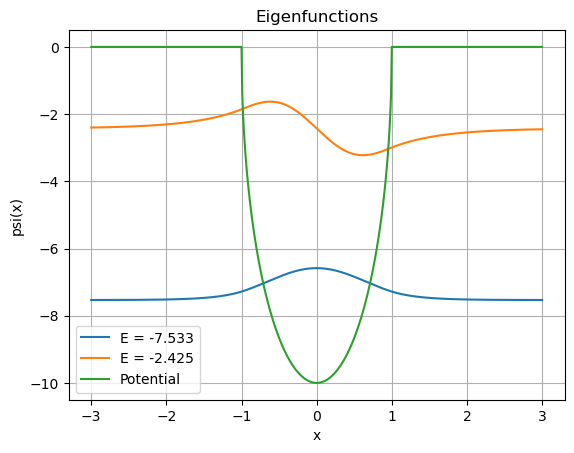

In [99]:
for E in En:
	xs, psi = eigenfunction(E, xm, xil, xfr, dx)
	plt.plot(xs, E + psi, label = f"E = {E: 0.3f}")
    
Vs = [V(x) for x in xs]
plt.plot(xs, Vs, label = "Potential")
plt.xlabel("x")
plt.ylabel("psi(x)")
plt.title("Eigenfunctions")

plt.legend()
plt.grid()
plt.show()

The 1st eigenfunction has 0 node while the 2nd eigenfunction has 1 node. The wavefunction oscillates inside and decays exponentially outside the potential well, as is expected from bound state solutions.